In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('Cleaned_Laptops_Data.xls')
df.head()

,Brand_name,Device_name,Operating system,Ram(in GB),Storage(in GB),Price(in ₹),Discount(in percentages),Rating,Warrenty
0,Samsung,Samsung Galaxy Book4 Metal Intel Core i5 13th ...,Windows 11 Home,8,512,52500,32.0,4.4,1 Year Manufacturer Warranty for Laptop and 6 ...
1,CHUWI,CHUWI Intel Core i3 10th Gen 10100Y,Windows 11 Home,8,256,19990,50.0,4.1,1 Year Onsite Warranty
2,Acer,Acer Aspire 3 (2025) Intel Core i5 13th Gen 1334U,Windows 11 Home,16,512,41800,50.0,4.2,3 Years Warranty
3,Acer,Acer Aspire 3 Intel Celeron Dual Core,Windows 11 Home,8,128,15990,51.0,3.8,1 Year Warranty
4,Acer,Acer Aspire 3 Intel Core i3 12th Gen 1215U,Windows 11 Home,8,512,27990,34.0,4.2,1 Year Domestic Warranty


In [4]:
# Numerical Columns
numeric_columns = df.select_dtypes(include=['number']).columns
numeric_columns

Index(['Ram(in GB)', 'Storage(in GB)', 'Price(in ₹)',
       'Discount(in percentages)', 'Rating'],
      dtype='object')

In [6]:
# Categorical Columns
categorical_columns = df.select_dtypes(exclude=np.number).columns
categorical_columns

Index(['Brand_name', 'Device_name', 'Operating system', 'Warrenty'], dtype='object')

## Uni-variate Analysis:

In [12]:
# Measures of Dispersion & Central Tendency
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ram(in GB),774.0,11.633075,4.613916,4.0,8.0,8.0,16.0,32.0
Storage(in GB),774.0,484.863049,79.637077,128.0,512.0,512.0,512.0,512.0
Price(in ₹),774.0,51699.145995,22726.613266,12490.0,35990.0,46940.0,66990.0,114100.0
Discount(in percentages),774.0,28.576227,12.021380,0.0,18.0,28.0,37.0,57.0
Rating,774.0,4.115116,0.649901,0.0,4.1,4.2,4.4,5.0


In [25]:
df.select_dtypes(include=['number']).median()

Ram(in GB)                      8.0
Storage(in GB)                512.0
Price(in ₹)                 46940.0
Discount(in percentages)       28.0
Rating                          4.2
dtype: float64

## Univariate Plots

### Continuous Data

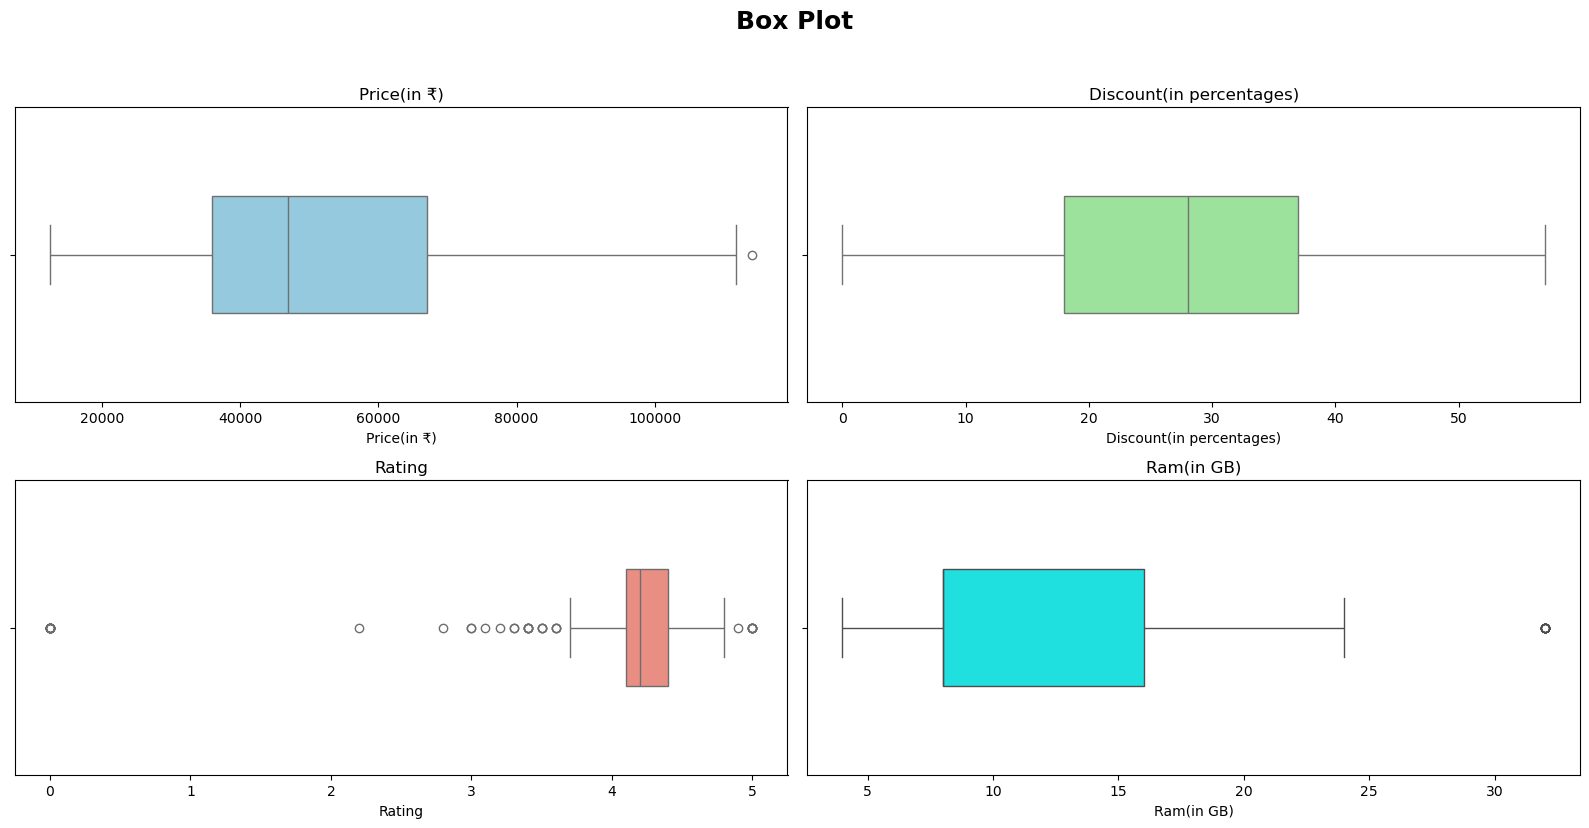

In [53]:
plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)

sns.boxplot(x=df["Price(in ₹)"], width=0.4, color='skyblue')
plt.title("Price(in ₹)")

plt.subplot(2, 2, 2)
sns.boxplot(x=df["Discount(in percentages)"], width=0.4, color='lightgreen')
plt.title("Discount(in percentages)")

plt.subplot(2, 2, 3)
sns.boxplot(x=df["Rating"], width=0.4, color='salmon')
plt.title("Rating")

plt.subplot(2, 2, 4)
sns.boxplot(x=df["Ram(in GB)"], width=0.4, color='cyan')
plt.title("Ram(in GB)")

plt.suptitle("Box Plot", fontsize=18, fontweight='bold', y=1.03)

plt.tight_layout()
plt.show()

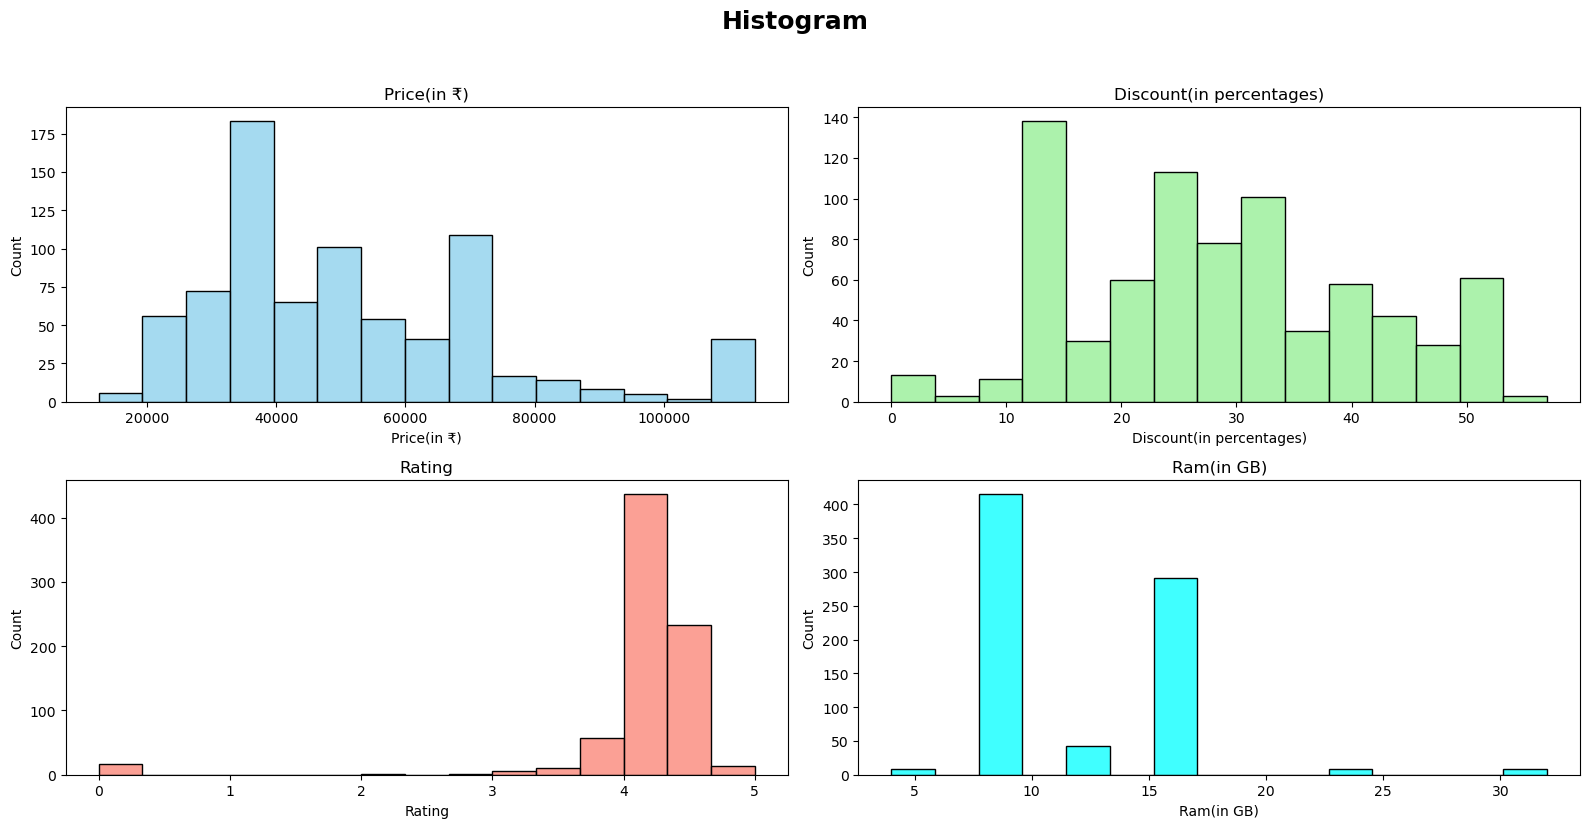

In [52]:
plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)

sns.histplot(x=df["Price(in ₹)"], bins=15, kde=False, color='skyblue')
plt.title("Price(in ₹)")

plt.subplot(2, 2, 2)
sns.histplot(x=df["Discount(in percentages)"], bins=15, kde=False, color='lightgreen')
plt.title("Discount(in percentages)")

plt.subplot(2, 2, 3)
sns.histplot(x=df["Rating"], bins=15, kde=False, color='salmon')
plt.title("Rating")

plt.subplot(2, 2, 4)
sns.histplot(x=df["Ram(in GB)"], bins=15, kde=False, color='cyan')
plt.title("Ram(in GB)")

plt.suptitle("Histogram", fontsize=18, fontweight='bold', y=1.03)

plt.tight_layout()
plt.show()

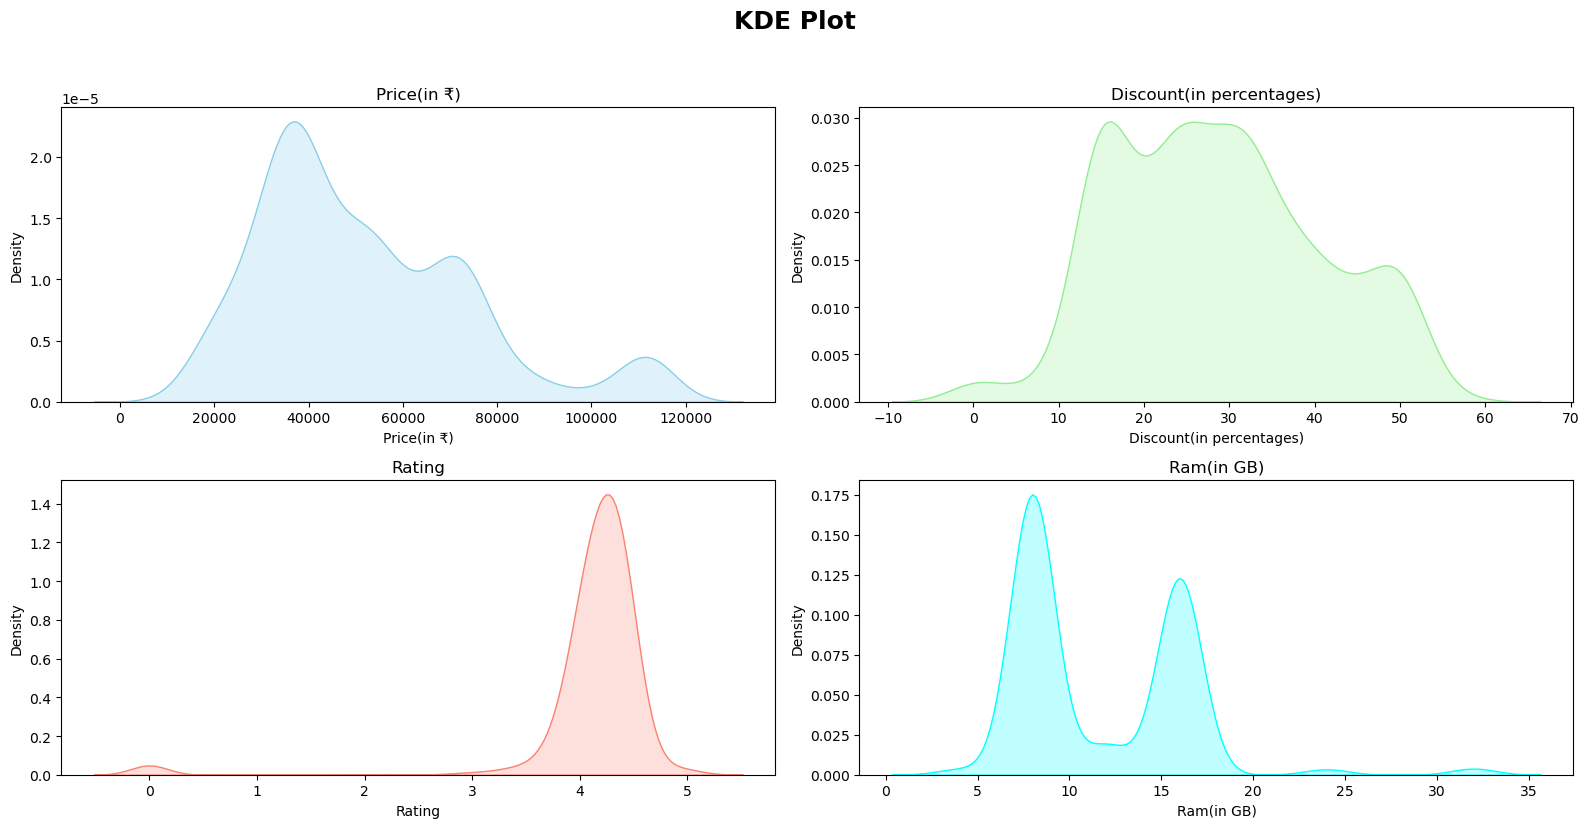

In [51]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)

sns.kdeplot(x=df["Price(in ₹)"], fill=True, color='skyblue')
plt.title("Price(in ₹)")

plt.subplot(2, 2, 2)
sns.kdeplot(x=df["Discount(in percentages)"], fill=True, color='lightgreen')
plt.title("Discount(in percentages)")

plt.subplot(2, 2, 3)
sns.kdeplot(x=df["Rating"], fill=True, color='salmon')
plt.title("Rating")

plt.subplot(2, 2, 4)
sns.kdeplot(x=df["Ram(in GB)"], fill=True, color='cyan')
plt.title("Ram(in GB)")

plt.suptitle("KDE Plot", fontsize=18, fontweight='bold', y=1.03)

plt.tight_layout()
plt.show()

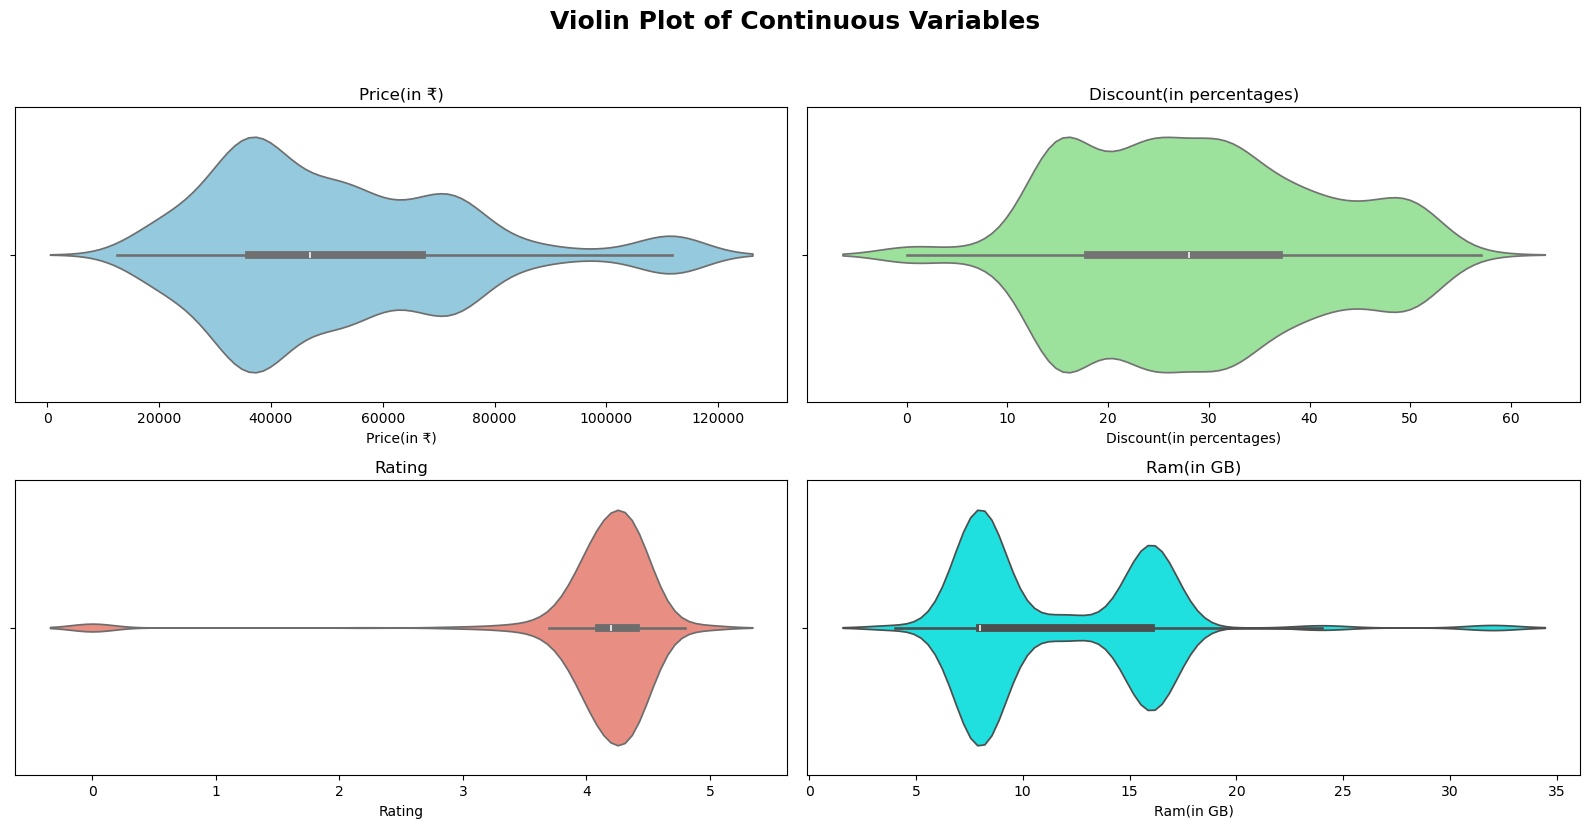

In [62]:
cols = ["Price(in ₹)", "Discount(in percentages)", "Rating", "Ram(in GB)"]
colors = ['skyblue', 'lightgreen', 'salmon', 'cyan']

plt.figure(figsize=(16, 8))

for i, (col, color) in enumerate(zip(cols, colors), 1):
    plt.subplot(2, 2, i)
    sns.violinplot(x=df[col], color=color)
    plt.title(col)

plt.suptitle("Violin Plot of Continuous Variables", fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

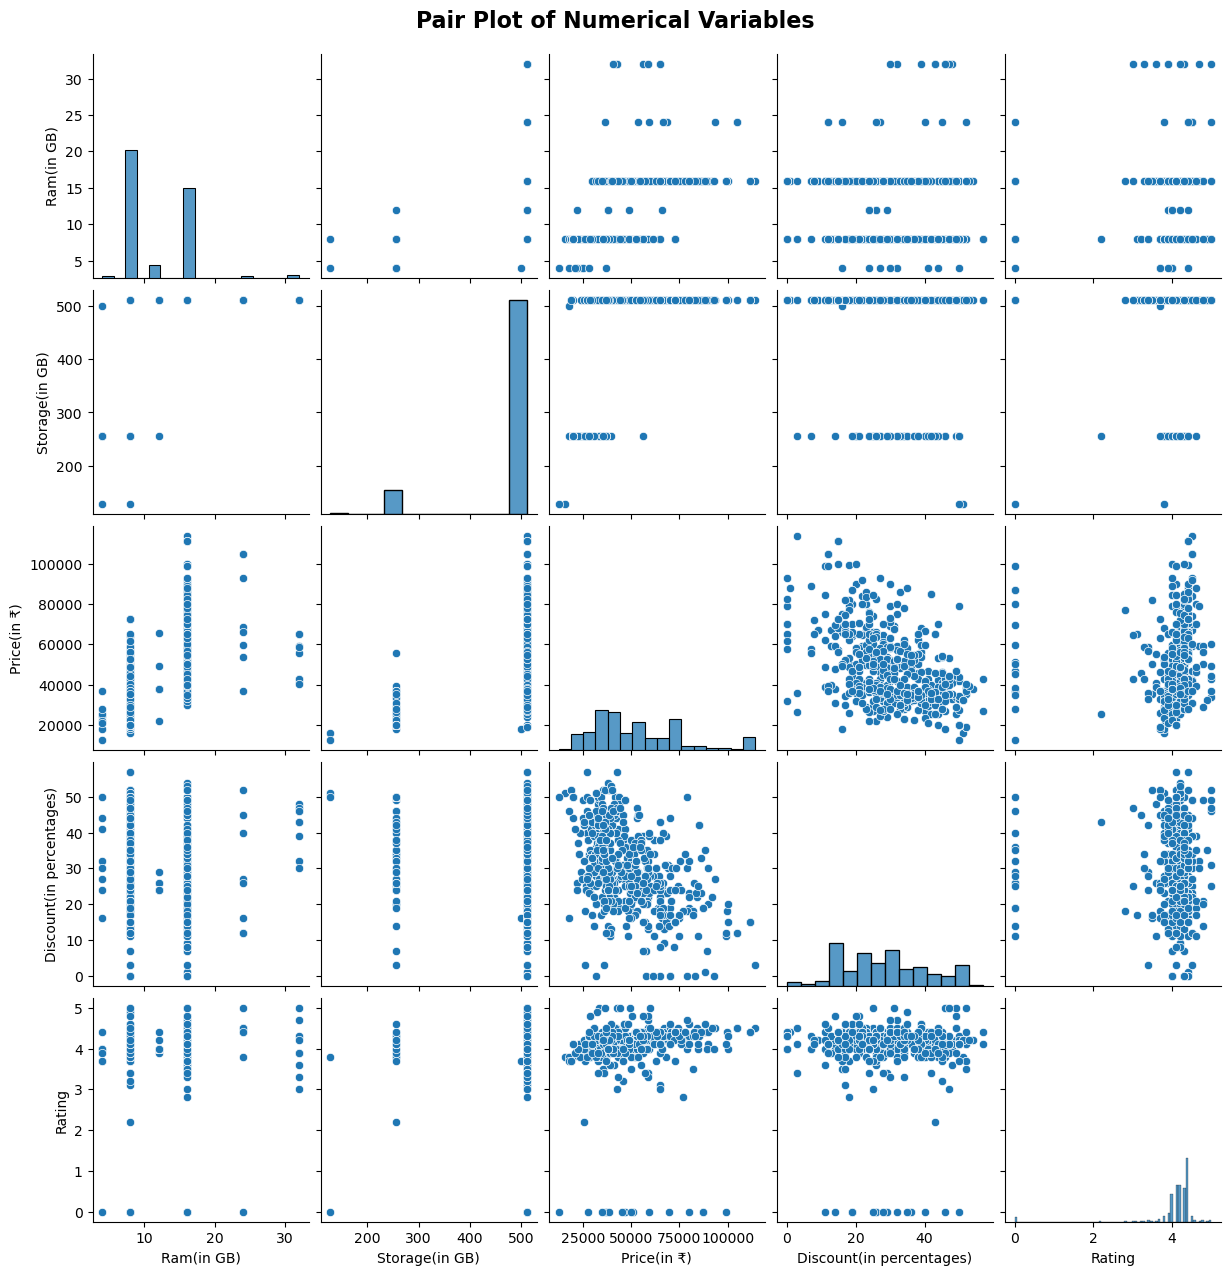

In [61]:
sns.pairplot(df.select_dtypes(include=['number']))
plt.suptitle("Pair Plot of Numerical Variables", fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [63]:
df.describe(exclude=np.number).T

,count,unique,top,freq
Brand_name,774,13,Samsung,171
Device_name,774,362,Samsung Galaxy Book4 Intel Core 5 120U,80
Operating system,774,8,Windows 11 Home,687
Warrenty,774,66,1 Year Onsite Warranty,284


### Categorical Data

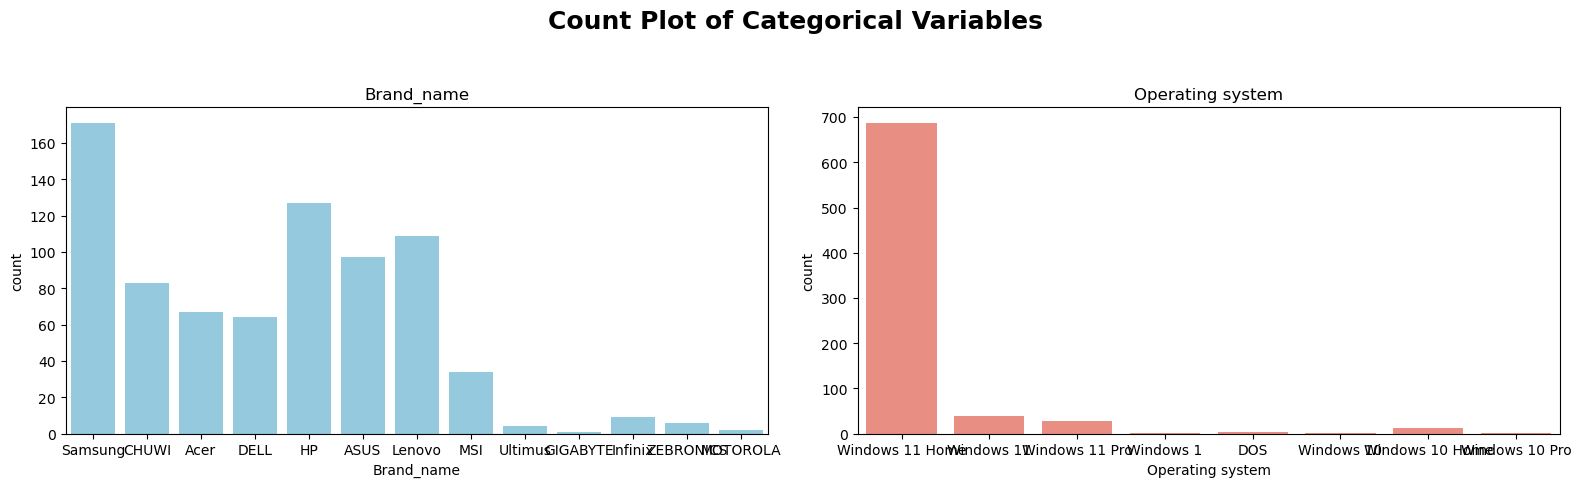

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["Brand_name", "Operating system"]
colors = ['skyblue', 'salmon']

plt.figure(figsize=(16, 8))

for i, (col, color) in enumerate(zip(cols, colors), 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=df[col], color=color)
    plt.title(col)

plt.suptitle("Count Plot of Categorical Variables", fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

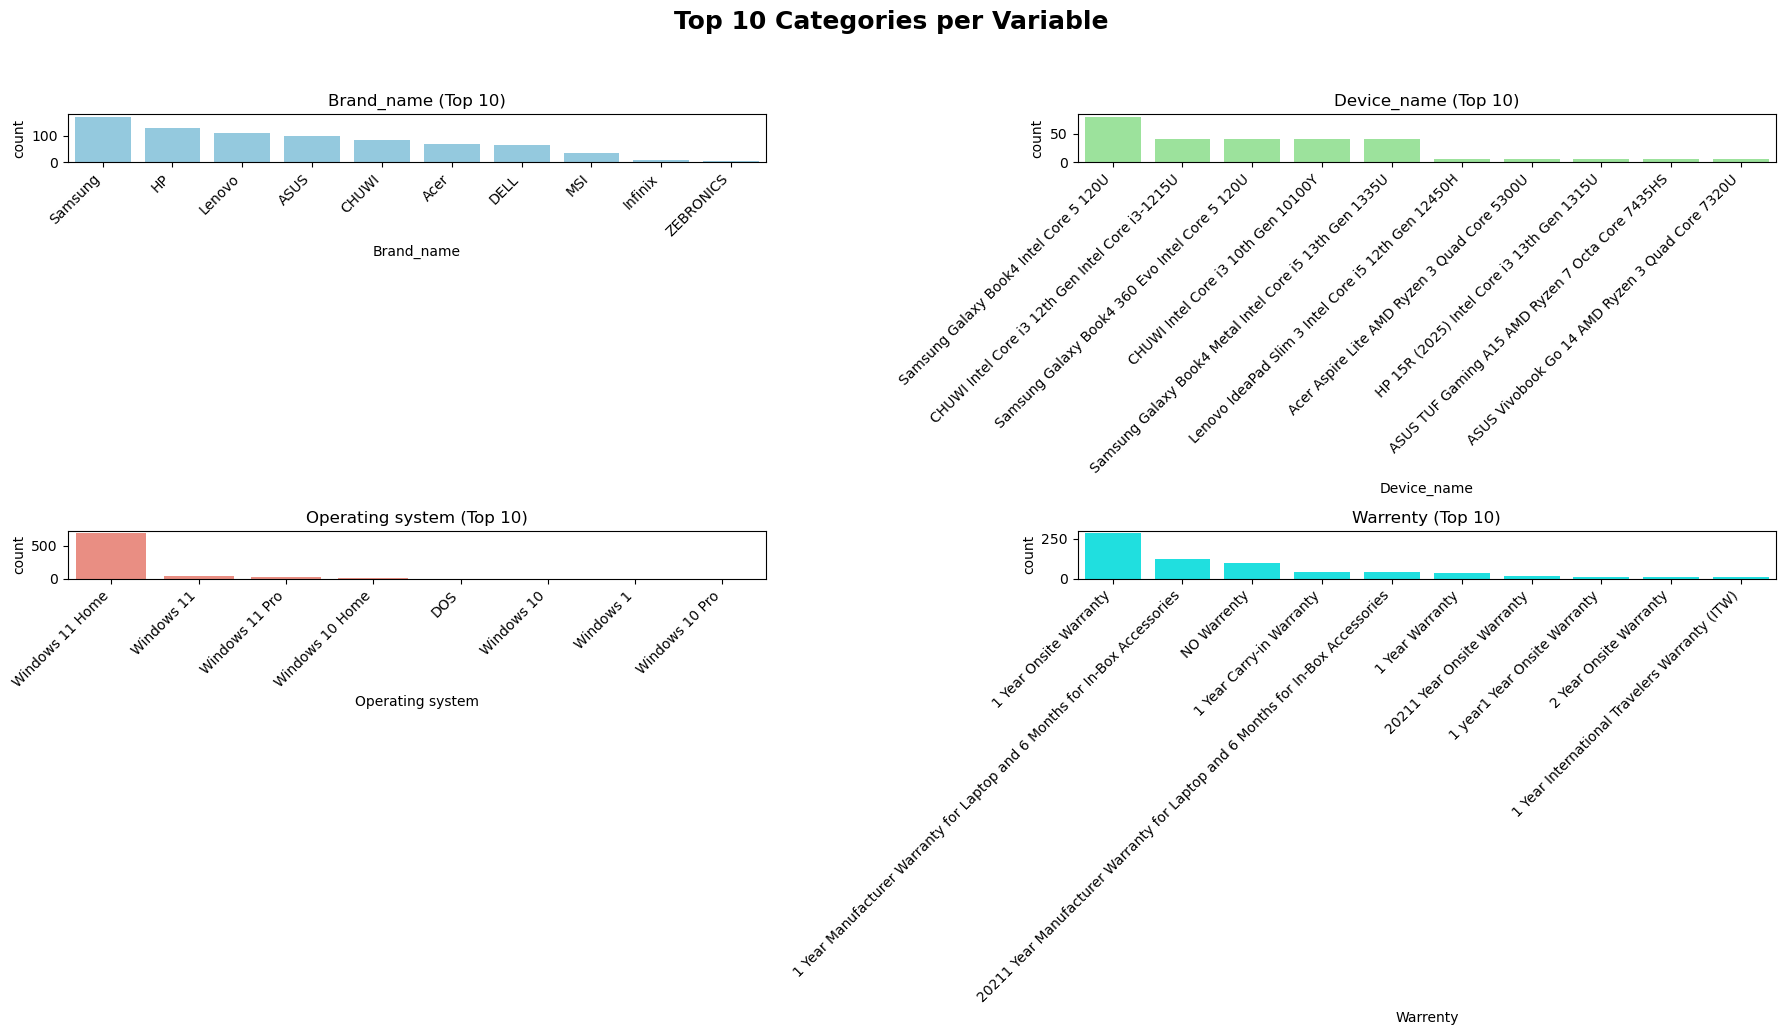

In [80]:
cols = ["Brand_name", "Device_name", "Operating system", "Warrenty"]
colors = ['skyblue', 'lightgreen', 'salmon', 'cyan']

plt.figure(figsize=(18, 10))

for i, (col, color) in enumerate(zip(cols, colors), 1):
    plt.subplot(2, 2, i)
    top_values = df[col].value_counts().nlargest(10).index
    sns.countplot(x=df[df[col].isin(top_values)][col], color=color, order=top_values)
    plt.title(f"{col} (Top 10)")
    plt.xticks(rotation=45, ha='right')

plt.suptitle("Top 10 Categories per Variable", fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


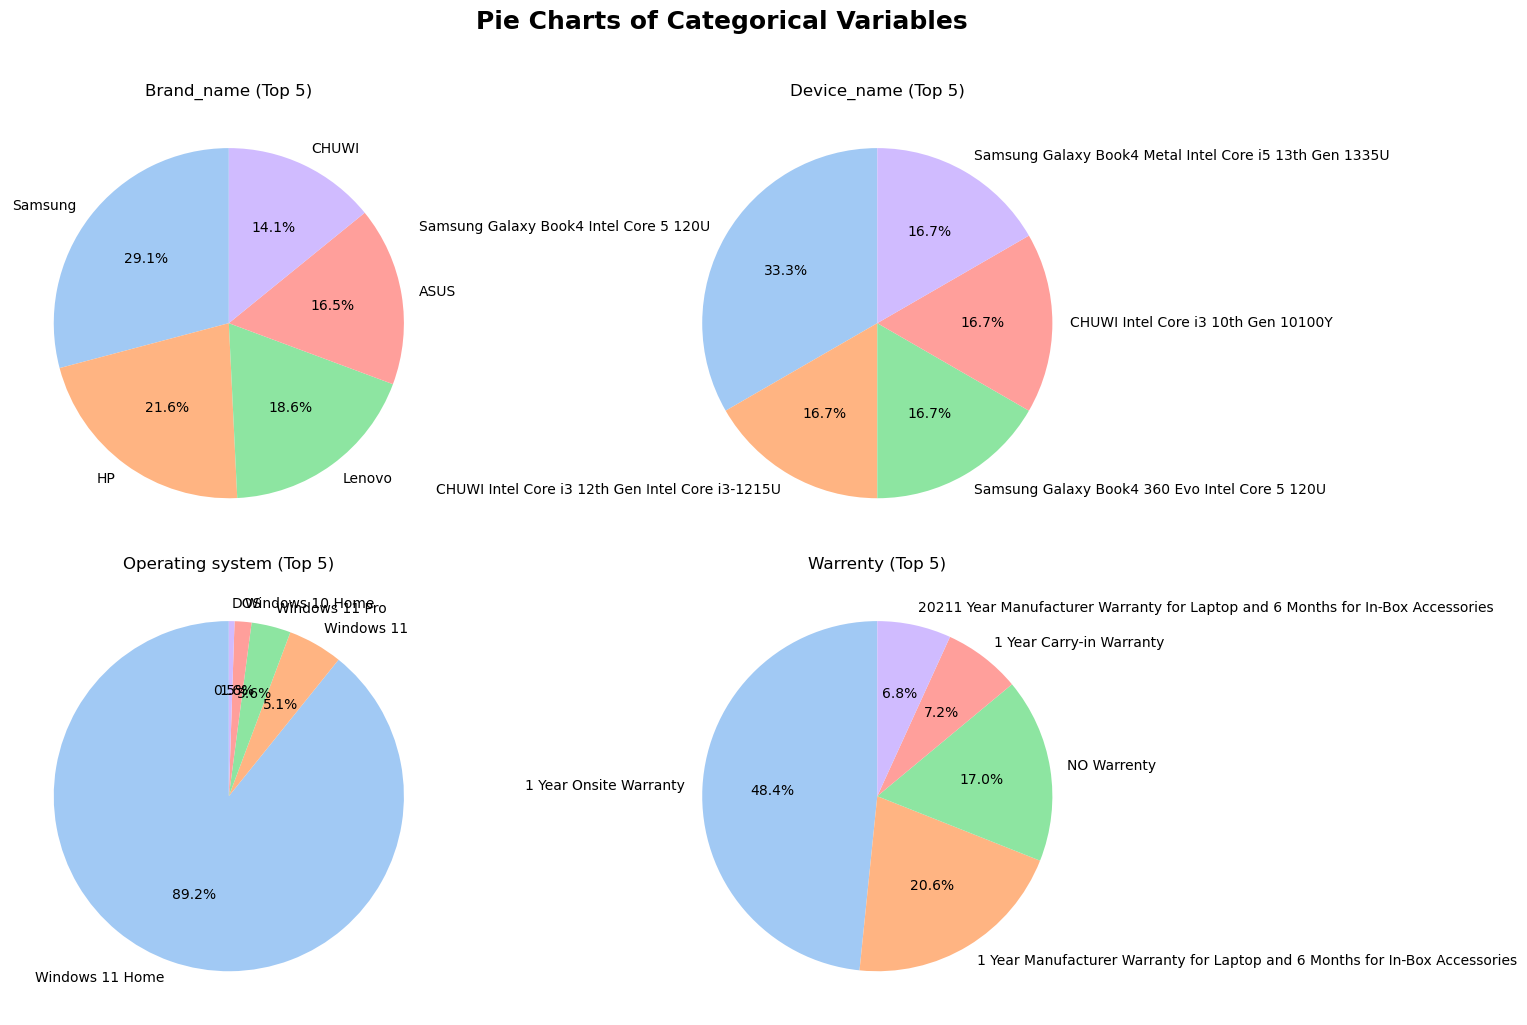

In [81]:
cols = ["Brand_name", "Device_name", "Operating system", "Warrenty"]
colors = ['skyblue', 'lightgreen', 'salmon', 'cyan']

plt.figure(figsize=(16, 10))

for i, (col, color) in enumerate(zip(cols, colors), 1):
    plt.subplot(2, 2, i)
    top_values = df[col].value_counts().nlargest(5)
    plt.pie(
        top_values.values,
        labels=top_values.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette("pastel", len(top_values))
    )
    plt.title(f"{col} (Top 5)")

plt.suptitle("Pie Charts of Categorical Variables", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Bi-variate Analysis :

In [83]:
# GroupBy
grouped = df.groupby("Brand_name")["Price(in ₹)"].mean().sort_values(ascending=False)
print(grouped)

Brand_name
GIGABYTE     78990.000000
Samsung      76988.233918
MOTOROLA     64990.000000
Infinix      57167.555556
MSI          50611.147059
ZEBRONICS    48964.166667
Lenovo       48950.339450
ASUS         47015.659794
DELL         46523.203125
Acer         45371.238806
HP           45027.677165
CHUWI        29002.048193
Ultimus      18240.000000
Name: Price(in ₹), dtype: float64


In [84]:
# Pivot Table (for multiple stats)
pivot_table = pd.pivot_table(df, values="Price(in ₹)", index="Brand_name", aggfunc=["mean", "median", "count"])
print(pivot_table)

                    mean      median       count
             Price(in ₹) Price(in ₹) Price(in ₹)
Brand_name                                      
ASUS        47015.659794     40099.0          97
Acer        45371.238806     37990.0          67
CHUWI       29002.048193     22990.0          83
DELL        46523.203125     42875.0          64
GIGABYTE    78990.000000     78990.0           1
HP          45027.677165     38990.0         127
Infinix     57167.555556     49679.0           9
Lenovo      48950.339450     45490.0         109
MOTOROLA    64990.000000     64990.0           2
MSI         50611.147059     49490.0          34
Samsung     76988.233918     72799.0         171
Ultimus     18240.000000     18990.0           4
ZEBRONICS   48964.166667     42699.0           6


In [85]:
cross_tab = pd.crosstab(df["Brand_name"], df["Operating system"])
print(cross_tab)

Operating system  DOS  Windows 1  Windows 10  Windows 10 Home  Windows 10 Pro  \
Brand_name                                                                      
ASUS                0          0           0                2               0   
Acer                0          0           0                0               0   
CHUWI               0          0           0                0               0   
DELL                0          0           2                0               0   
GIGABYTE            0          0           0                0               0   
HP                  1          1           0                9               1   
Infinix             0          0           0                0               0   
Lenovo              3          0           0                1               0   
MOTOROLA            0          0           0                0               0   
MSI                 0          0           0                0               0   
Samsung             0       

### Continuous vs Continuous

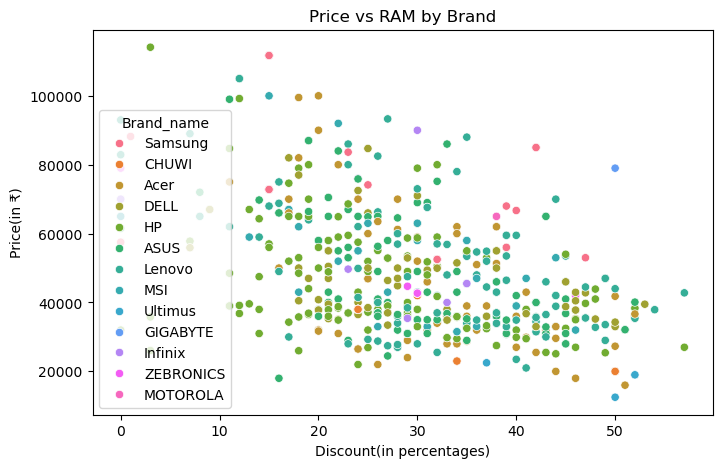

In [92]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Discount(in percentages)", y="Price(in ₹)", data=df, hue="Brand_name")
plt.title("Price vs RAM by Brand")
plt.show()

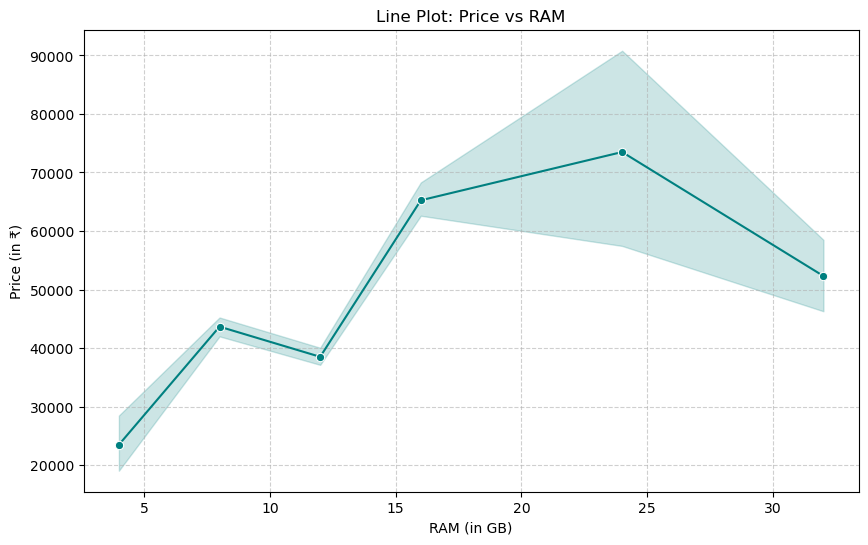

In [93]:
plt.figure(figsize=(10, 6))
sns.lineplot(x="Ram(in GB)", y="Price(in ₹)", data=df, marker='o', color='teal')
plt.title("Line Plot: Price vs RAM")
plt.xlabel("RAM (in GB)")
plt.ylabel("Price (in ₹)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Continuous vs Categorical

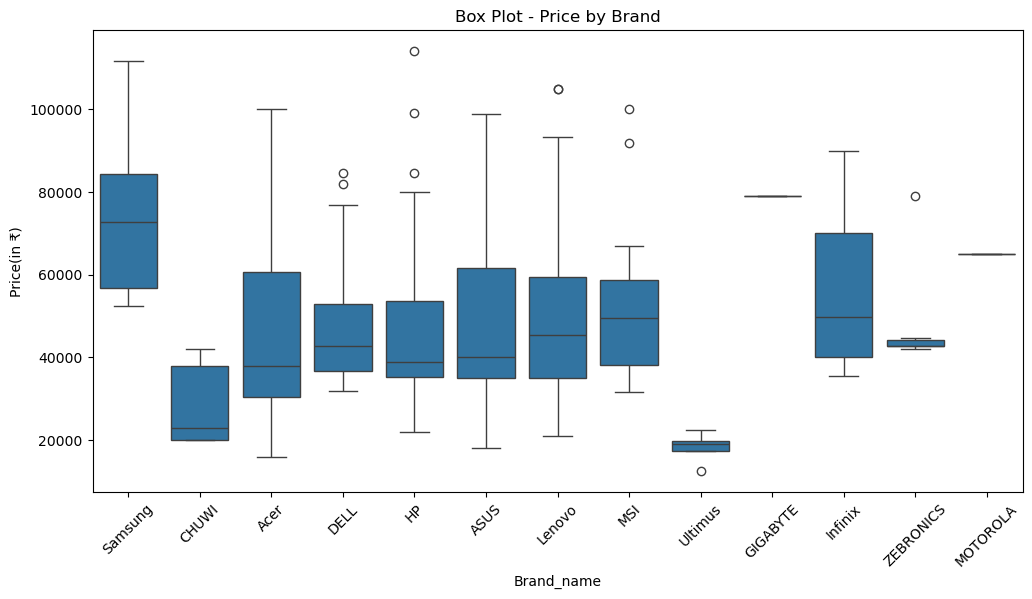

In [94]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="Brand_name", y="Price(in ₹)", data=df)
plt.title("Box Plot - Price by Brand")
plt.xticks(rotation=45)
plt.show()

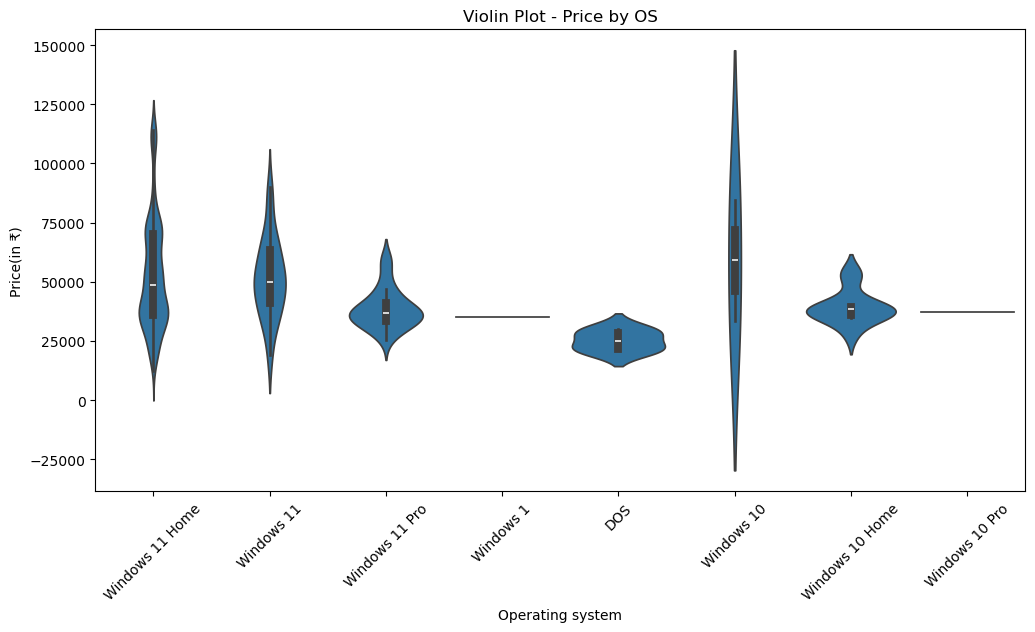

In [95]:
plt.figure(figsize=(12, 6))
sns.violinplot(x="Operating system", y="Price(in ₹)", data=df)
plt.title("Violin Plot - Price by OS")
plt.xticks(rotation=45)
plt.show()

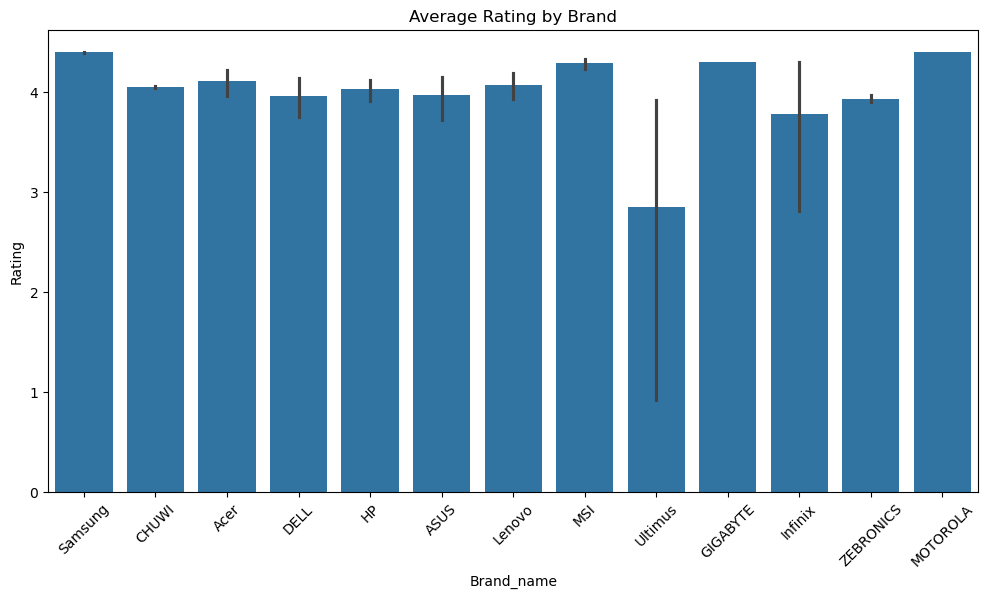

In [96]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Brand_name", y="Rating", data=df, estimator="mean")
plt.title("Average Rating by Brand")
plt.xticks(rotation=45)
plt.show()

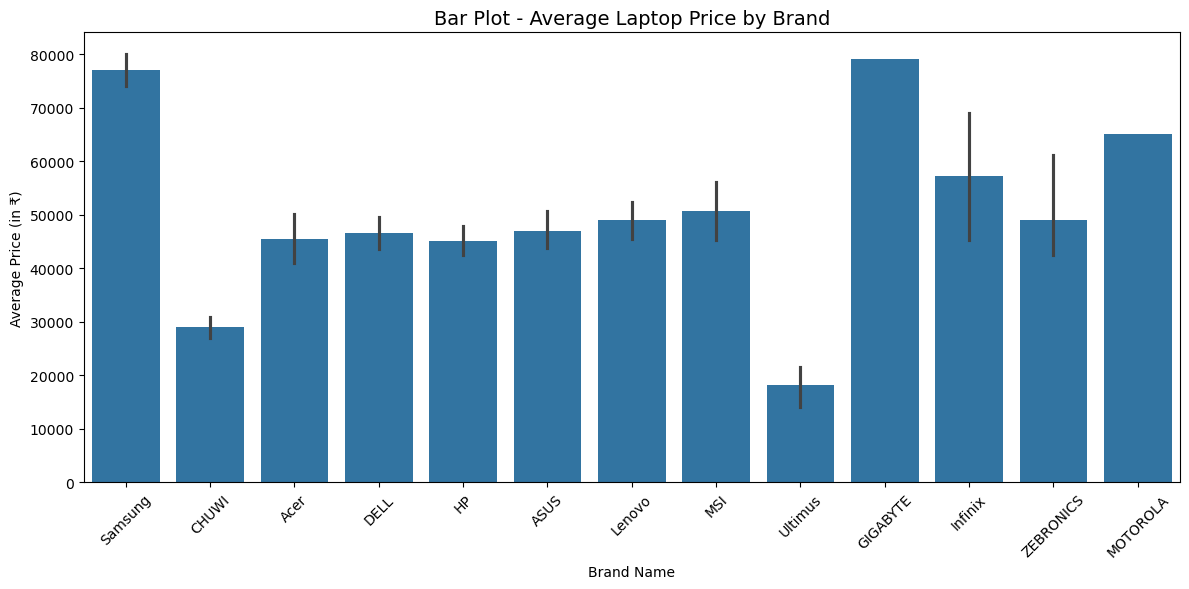

In [5]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Brand_name", y="Price(in ₹)", data=df, estimator='mean')
plt.title("Bar Plot - Average Laptop Price by Brand", fontsize=14)
plt.xlabel("Brand Name")
plt.ylabel("Average Price (in ₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Categorical vs Categorical Variables

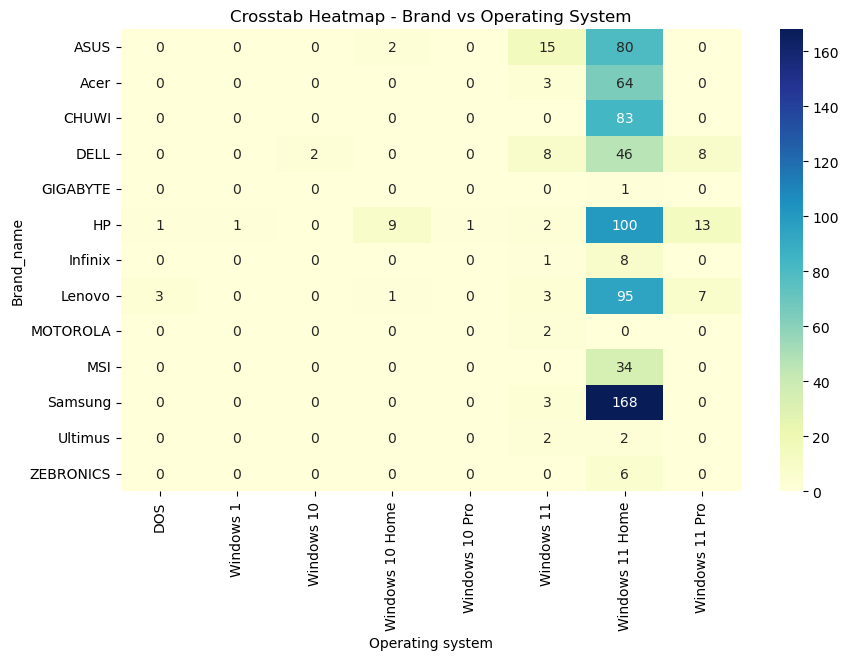

In [97]:
plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab, cmap="YlGnBu", annot=True, fmt="d")
plt.title("Crosstab Heatmap - Brand vs Operating System")
plt.show()

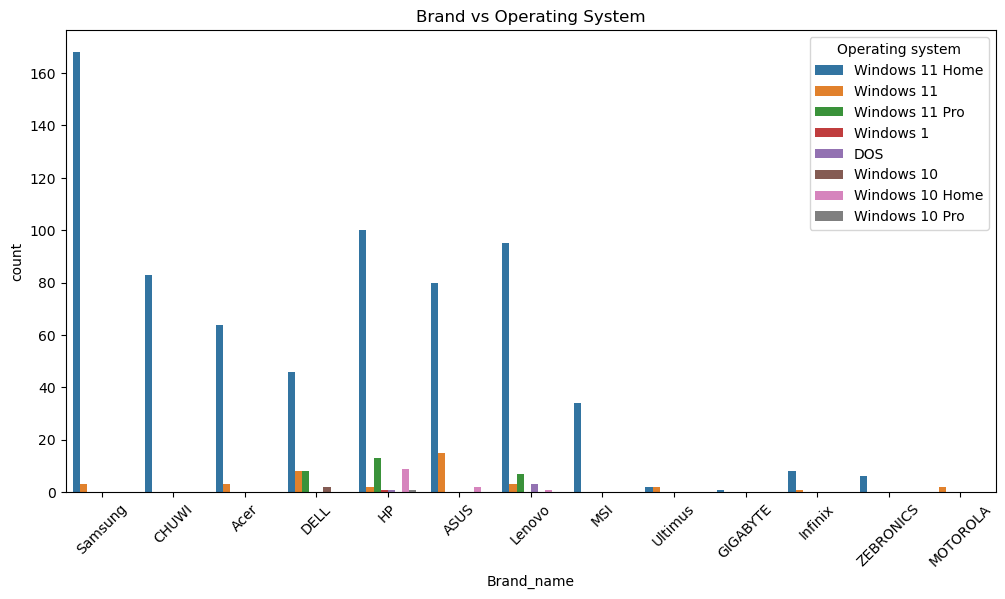

In [98]:
plt.figure(figsize=(12, 6))
sns.countplot(x="Brand_name", hue="Operating system", data=df)
plt.title("Brand vs Operating System")
plt.xticks(rotation=45)
plt.show()

## Multivariate Analysis

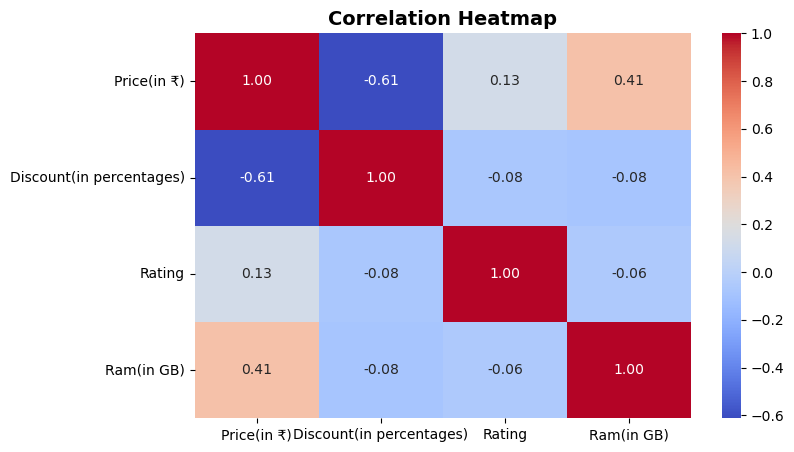

In [102]:
# Correlation Matrix
corr = df[["Price(in ₹)", "Discount(in percentages)", "Rating", "Ram(in GB)"]].corr()

# Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.show()

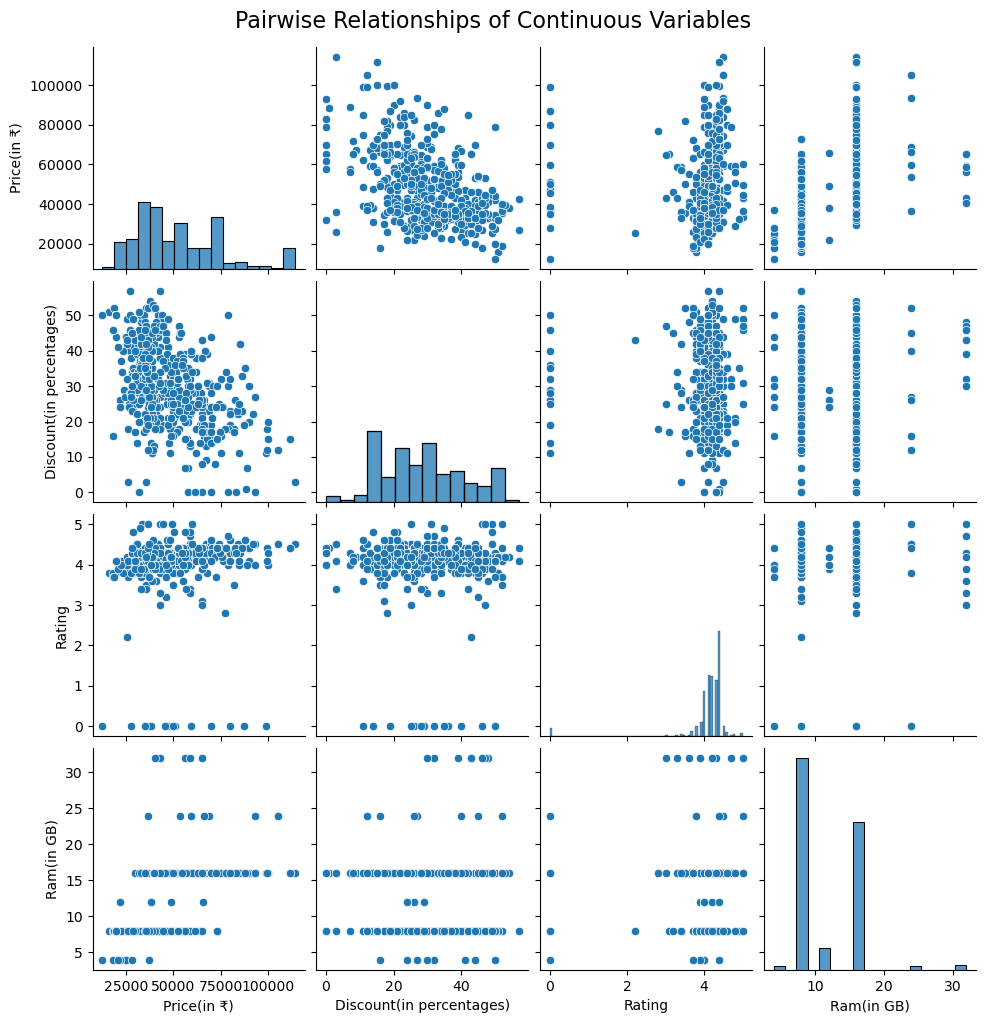

In [106]:
sns.pairplot(df[["Price(in ₹)", "Discount(in percentages)", "Rating", "Ram(in GB)"]])
plt.suptitle("Pairwise Relationships of Continuous Variables", fontsize=16, y=1.02)
plt.show()